In [1]:
import os, pickle

import loompy as lp
import pandas as pd

from pyscenic.utils import load_motifs
from pyscenic.prune import df2regulons
from pyscenic.utils import load_motifs

from pyscenic.binarization import binarize

In [2]:
pdir = "/dcs04/lieber/marmaypag/spatialDLPFC_mdd_bpd_LIBD4100/spatialDLPFC_mdd_bpd/"

## Load modules

In [4]:
df = pd.read_csv(pdir+"processed-data/09_SCENIC/single-slide_reg.csv", skiprows=1)
df.columns = ['TF','MotifID', *df.columns[2:]]
df = df.iloc[1:]

In [6]:
df_motifs = load_motifs(pdir+"processed-data/09_SCENIC/single-slide_reg.csv")

In [7]:
df_motifs.head()

Enrichment                                  \
                                      AUC       NES MotifSimilarityQvalue   
TF      MotifID                                                             
ARX     metacluster_9.34         0.083924  3.019752          8.417510e-06   
ATF2    swissregulon__mm__Atf2   0.083111  3.238244          0.000000e+00   
BCL11A  hdpi__BCL11A             0.074397  3.251257          0.000000e+00   
BHLHE40 metacluster_128.2        0.077545  3.472684          0.000000e+00   
BPTF    tfdimers__MD00089        0.081606  3.091867          8.583560e-07   

                                                    \
                               OrthologousIdentity   
TF      MotifID                                      
ARX     metacluster_9.34                  0.960854   
ATF2    swissregulon__mm__Atf2            0.991786   
BCL11A  hdpi__BCL11A                      1.000000   
BHLHE40 metacluster_128.2                 1.000000   
BPTF    tfdimers__MD00089                 1.000000   

                                                                                   \
                                                                       Annotation   
TF      MotifID                                                                     
ARX     metacluster_9.34        gene is orthologous to ENSMUSG00000035277 in M...   
ATF2    swissregulon__mm__Atf2  motif is annotated for orthologous gene ENSMUS...   
BCL11A  hdpi__BCL11A                                   gene is directly annotated   
BHLHE40 metacluster_128.2                              gene is directly annotated   
BPTF    tfdimers__MD00089       gene is annotated for similar motif tfdimers__...   

                                                                                   \
                                                                          Context   
TF      MotifID                                                                     
ARX     metacluster_9.34        (hg38_500bp_up_100bp_down_full_tx_v10_clust.ge...   
ATF2    swissregulon__mm__Atf2  (hg38_500bp_up_100bp_down_full_tx_v10_clust.ge...   
BCL11A  hdpi__BCL11A            (hg38_500bp_up_100bp_down_full_tx_v10_clust.ge...   
BHLHE40 metacluster_128.2       (hg38_500bp_up_100bp_down_full_tx_v10_clust.ge...   
BPTF    tfdimers__MD00089       (hg38_500bp_up_100bp_down_full_tx_v10_clust.ge...   

                                                                                   \
                                                                      TargetGenes   
TF      MotifID                                                                     
ARX     metacluster_9.34        [(TAC1, 0.5013436321605489), (LHX6, 1.94364495...   
ATF2    swissregulon__mm__Atf2  [(LINC00467, 0.9385156614855804), (TMEM209, 0....   
BCL11A  hdpi__BCL11A            [(BCL11A, 1.0), (ZBTB37, 1.9322534596194567), ...   
BHLHE40 metacluster_128.2       [(CDC73, 4.131046630854925), (LYPLAL1, 0.37707...   
BPTF    tfdimers__MD00089       [(RRAGB, 0.8644071041181793), (BPTF, 1.0), (AF...   

                                          
                               RankAtMax  
TF      MotifID                           
ARX     metacluster_9.34             453  
ATF2    swissregulon__mm__Atf2      1253  
BCL11A  hdpi__BCL11A                1118  
BHLHE40 metacluster_128.2            593  
BPTF    tfdimers__MD00089           3825

In [13]:
import operator as op
from IPython.display import HTML, display

In [20]:
BASE_URL = "http://motifcollections.aertslab.org/v9/logos/"
COLUMN_NAME_LOGO = "MotifLogo"
COLUMN_NAME_MOTIF_ID = "MotifID"
COLUMN_NAME_TARGETS = "TargetGenes"

def display_logos(df: pd.DataFrame, top_target_genes: int = 3, base_url: str = BASE_URL):
    """
    :param df:
    :param base_url:
    """
    # Make sure the original dataframe is not altered.
    df = df.copy()
    
    # Add column with URLs to sequence logo.
    def create_url(motif_id):
        return '<img src="{}{}.png" style="max-height:124px;"></img>'.format(base_url, motif_id)
    df[("Enrichment", COLUMN_NAME_LOGO)] = list(map(create_url, df.index.get_level_values(COLUMN_NAME_MOTIF_ID)))
    
    # Truncate TargetGenes.
    def truncate(col_val):
        return sorted(col_val, key=op.itemgetter(1))[:top_target_genes]
    df[("Enrichment", COLUMN_NAME_TARGETS)] = list(map(truncate, df[("Enrichment", COLUMN_NAME_TARGETS)]))
    
    MAX_COL_WIDTH = pd.get_option('display.max_colwidth')
    pd.set_option('display.max_colwidth', None)
    display(HTML(df.head().to_html(escape=False)))
    pd.set_option('display.max_colwidth', MAX_COL_WIDTH)

In [24]:
def create_url(motif_id, base_url: str = BASE_URL):
    return '<img src="{}{}.png" style="max-height:124px;"></img>'.format(base_url, motif_id)

In [33]:
display(HTML(create_url("hdpi__BCL11A")))

In [34]:
display_logos(df_motifs.head())

In [ ]:
BASE_URL = "http://motifcollections.aertslab.org/v9/logos/"
def fetch_logo(regulon, base_url = BASE_URL):
    for elem in regulon.context:
        if elem.endswith('.png'):
            return '<img src="{}{}" style="max-height:124px;"></img>'.format(base_url, elem)
    return ""

## regulon from module
https://github.com/aertslab/pySCENIC/blob/06bafba412792f6efa5a552a23bb221cc3bdea1b/src/pyscenic/transform.py#L494

In [35]:
df = df_motifs.copy()

# Normally the columns index has two levels. For convenience of the following code the first level is removed.
if df.columns.nlevels == 2:
    df.columns = df.columns.droplevel(0)

In [38]:
COLUMN_NAME_CONTEXT = "Context"
COLUMN_NAME_TYPE = "Type"
ACTIVATING_MODULE = "activating"
REPRESSING_MODULE = "repressing"

def get_type(row):
    ctx = row[COLUMN_NAME_CONTEXT]
    # Activating is the default!
    return REPRESSING_MODULE if REPRESSING_MODULE in ctx else ACTIVATING_MODULE

df[COLUMN_NAME_TYPE] = df.apply(get_type, axis=1)

In [41]:
from pyscenic.transform import _regulon4group

In [45]:
COLUMN_NAME_TF = "TF"
save_columns = ['NES']
# Group all rows per TF and type (+)/(-). Each group results in a single regulon.
not_none = lambda r: r is not None
list(
    filter(
        not_none,
        (
            _regulon4group(
                tf_name, frozenset([interaction_type]), df_grp, save_columns
            )
            for (tf_name, interaction_type), df_grp in df.groupby(
                by=[COLUMN_NAME_TF, COLUMN_NAME_TYPE]
            )
        ),
    )
)

[Regulon(name='AHR(+)', gene2weight=frozendict.frozendict({'KANK1': 0.954702700533215, 'RBM38': 0.7674047432716449, 'GLRA2': 0.7488838131729024, 'STX17-AS1': 4.390062393407509, 'ZNF613': 2.647706570914656, 'ERN1': 0.2169007265127618, 'CENPBD1': 1.6057455446840094, 'AHR': 1.0, 'USP28': 1.387499822840464, 'APPL2': 0.5307291292486176}), gene2occurrence=frozendict.frozendict({}), transcription_factor='AHR', context=frozenset({'activating', 'metacluster_198.7.png'}), score=3.210330652402544, nes=3.210330652402544, orthologous_identity=0.0, similarity_qvalue=0.0, annotation=''),
 Regulon(name='AR(-)', gene2weight=frozendict.frozendict({'RNF19A': 0.1097656915192859, 'GRM5': 0.0361986682468323, 'RXFP1': 0.076065529477048, 'MFAP3L': 0.0791947812470458, 'A2M': 0.1931880001538631, 'DGAT1': 0.0840494964901067}), gene2occurrence=frozendict.frozendict({}), transcription_factor='AR', context=frozenset({'taipale_tf_pairs__TEAD4_ESRRB_RCATTCYNNNNCAAGGTCAN_CAP_repr.png', 'repressing'}), score=3.02503323

## AUCell

In [3]:
lf = lp.connect("/dcs04/lieber/marmaypag/spatialDLPFC_mdd_bpd_LIBD4100/spatialDLPFC_mdd_bpd/processed-data/09_SCENIC/spe-n119_21077_AUCell-output.loom", mode='r+', validate=False)
auc_mtx = pd.DataFrame(lf.ca.RegulonsAUC, index=lf.ca.CellID)
domain_df = pd.DataFrame({"cluster": lf.ca.smoothed_k9_1663}, index=lf.ca.CellID)
lf.close()

https://htmlpreview.github.io/?https://github.com/aertslab/SCENICprotocol/blob/master/notebooks/SCENIC%20Protocol%20-%20Case%20study%20-%20Cancer%20data%20sets.html <br>
"To find cell type specific regulators we use a Z score (i.e. the average AUCell score for the cells of a give type are standardized using the overall average AUCell scores and its standard deviation)."

In [23]:
auc_mtx.head()

,AR(+),ATF3(+),ATF3(-),BARX2(+),CEBPD(+),DLX4(+),DLX5(+),EBF1(+),EHF(+),ELF1(+),...,ZNF283(+),ZNF284(+),ZNF296(+),ZNF578(-),ZNF699(+),ZNF718(+),ZNF730(+),ZNF773(-),ZNF836(+),ZNF837(+)
GACCTGGTCTGGGCGT-1_V13F27-338_A1,0.0,0.000000,0.0,0.0,0.010526,0.0,0.0,0.0,0.119307,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
CGTCCAGATGGCTCCA-1_V13F27-338_A1,0.0,0.002406,0.0,0.0,0.014710,0.0,0.0,0.0,0.214896,0.000000,...,0.046727,0.002588,0.0,0.0,0.0,0.0,0.0,0.0,0.004364,0.0
TCGCACTAACGTTTGT-1_V13F27-338_A1,0.0,0.016807,0.0,0.0,0.016260,0.0,0.0,0.0,0.000000,0.012845,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
TAGAAACACAATAGTG-1_V13F27-338_A1,0.0,0.005591,0.0,0.0,0.006189,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
GCGATGTCTGTGCTTG-1_V13F27-338_A1,0.0,0.057265,0.0,0.0,0.015178,0.0,0.0,0.0,0.053843,0.000000,...,0.000000,0.014835,0.0,0.0,0.0,0.0,0.0,0.0,0.013346,0.0


In [ ]:
signature_column_names = list(auc_mtx.select_dtypes('number').columns)

In [42]:
df_scores = auc_mtx.join(domain_df)

In [43]:
df_scores.head()

,AR(+),ATF3(+),ATF3(-),BARX2(+),CEBPD(+),DLX4(+),DLX5(+),EBF1(+),EHF(+),ELF1(+),...,ZNF284(+),ZNF296(+),ZNF578(-),ZNF699(+),ZNF718(+),ZNF730(+),ZNF773(-),ZNF836(+),ZNF837(+),cluster
GACCTGGTCTGGGCGT-1_V13F27-338_A1,0.0,0.000000,0.0,0.0,0.010526,0.0,0.0,0.0,0.119307,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,L3.4
CGTCCAGATGGCTCCA-1_V13F27-338_A1,0.0,0.002406,0.0,0.0,0.014710,0.0,0.0,0.0,0.214896,0.000000,...,0.002588,0.0,0.0,0.0,0.0,0.0,0.0,0.004364,0.0,L3.4
TCGCACTAACGTTTGT-1_V13F27-338_A1,0.0,0.016807,0.0,0.0,0.016260,0.0,0.0,0.0,0.000000,0.012845,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,L3.4
TAGAAACACAATAGTG-1_V13F27-338_A1,0.0,0.005591,0.0,0.0,0.006189,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,L5
GCGATGTCTGTGCTTG-1_V13F27-338_A1,0.0,0.057265,0.0,0.0,0.015178,0.0,0.0,0.0,0.053843,0.000000,...,0.014835,0.0,0.0,0.0,0.0,0.0,0.0,0.013346,0.0,L5


In [81]:
df_scores[-df_scores['cluster'].isin(['Vasc','GABA'])]

,AR(+),ATF3(+),ATF3(-),BARX2(+),CEBPD(+),DLX4(+),DLX5(+),EBF1(+),EHF(+),ELF1(+),...,ZNF284(+),ZNF296(+),ZNF578(-),ZNF699(+),ZNF718(+),ZNF730(+),ZNF773(-),ZNF836(+),ZNF837(+),cluster
GACCTGGTCTGGGCGT-1_V13F27-338_A1,0.00000,0.000000,0.0,0.0,0.010526,0.000000,0.0,0.0,0.119307,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,L3.4
CGTCCAGATGGCTCCA-1_V13F27-338_A1,0.00000,0.002406,0.0,0.0,0.014710,0.000000,0.0,0.0,0.214896,0.000000,...,0.002588,0.0,0.0,0.0,0.000000,0.0,0.0,0.004364,0.0,L3.4
TCGCACTAACGTTTGT-1_V13F27-338_A1,0.00000,0.016807,0.0,0.0,0.016260,0.000000,0.0,0.0,0.000000,0.012845,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,L3.4
TAGAAACACAATAGTG-1_V13F27-338_A1,0.00000,0.005591,0.0,0.0,0.006189,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,L5
GCGATGTCTGTGCTTG-1_V13F27-338_A1,0.00000,0.057265,0.0,0.0,0.015178,0.000000,0.0,0.0,0.053843,0.000000,...,0.014835,0.0,0.0,0.0,0.000000,0.0,0.0,0.013346,0.0,L5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTCGGACTGATGCCTT-1_V13B23-282_D1,0.06129,0.014808,0.0,0.0,0.011524,0.000000,0.0,0.0,0.040085,0.000000,...,0.009746,0.0,0.0,0.0,0.000000,0.0,0.0,0.009614,0.0,L5
ACATTTGAAACCTAAC-1_V13B23-282_D1,0.00000,0.060213,0.0,0.0,0.033381,0.000000,0.0,0.0,0.117410,0.000000,...,0.037951,0.0,0.0,0.0,0.046679,0.0,0.0,0.081025,0.0,L2
AGAATACAGGCTATCC-1_V13B23-282_D1,0.00000,0.006574,0.0,0.0,0.020007,0.070999,0.0,0.0,0.043880,0.000000,...,0.011040,0.0,0.0,0.0,0.000000,0.0,0.0,0.010626,0.0,L2
ACCTCAGCGAGGCGCA-1_V13B23-282_D1,0.00000,0.031072,0.0,0.0,0.014212,0.000000,0.0,0.0,0.000000,0.023391,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,L2


In [57]:
df_scores.groupby(by='cluster').mean()

,AR(+),ATF3(+),ATF3(-),BARX2(+),CEBPD(+),DLX4(+),DLX5(+),EBF1(+),EHF(+),ELF1(+),...,ZNF283(+),ZNF284(+),ZNF296(+),ZNF578(-),ZNF699(+),ZNF718(+),ZNF730(+),ZNF773(-),ZNF836(+),ZNF837(+)
cluster,,,,,,,,,,,,,,,,,,,,,
GABA,0.001328,0.027265,0.001761,0.002490,0.021329,0.004114,0.022175,0.004151,0.015518,0.009897,...,0.004483,0.005470,0.000262,0.002609,0.001514,0.010435,0.053599,0.002074,0.008967,0.001901
L1,0.011724,0.047038,0.002260,0.003539,0.030179,0.002472,0.007329,0.015784,0.107451,0.011089,...,0.009265,0.039789,0.000448,0.002530,0.002445,0.045975,0.021057,0.001562,0.032323,0.002183
L2,0.002173,0.022084,0.001076,0.001506,0.018547,0.001620,0.005908,0.003314,0.018502,0.005194,...,0.002503,0.005888,0.000237,0.001091,0.001353,0.007949,0.005269,0.001525,0.006777,0.001538
L3.4,0.001878,0.020840,0.000690,0.001162,0.015311,0.001019,0.002388,0.002728,0.016209,0.004410,...,0.002161,0.005382,0.000202,0.000973,0.001093,0.007251,0.002099,0.001281,0.005539,0.001000
L5,0.001588,0.016623,0.000484,0.001434,0.012133,0.000814,0.001094,0.002502,0.010476,0.003591,...,0.001732,0.003501,0.000159,0.000702,0.001021,0.005774,0.001576,0.001809,0.003621,0.000759
L6,0.002624,0.020271,0.000846,0.001626,0.015008,0.001262,0.001466,0.003262,0.025552,0.004541,...,0.003283,0.008788,0.000262,0.001078,0.001464,0.011222,0.001822,0.002168,0.007990,0.000981
Vasc,0.013141,0.076068,0.007429,0.003359,0.054345,0.002677,0.009902,0.102127,0.104582,0.038597,...,0.013051,0.040239,0.000422,0.006627,0.003235,0.056361,0.007275,0.001445,0.050868,0.003152
WM,0.003590,0.040489,0.003065,0.002469,0.021009,0.001948,0.002753,0.007775,0.049188,0.010873,...,0.011939,0.016744,0.000495,0.002153,0.002807,0.022596,0.002447,0.002225,0.014767,0.001777
low.UMI,0.039554,0.064233,0.001018,0.001545,0.030357,0.003737,0.002268,0.007770,0.171583,0.004912,...,0.004510,0.077229,0.000355,0.000803,0.001308,0.091309,0.003922,0.000805,0.046756,0.001078


In [73]:
df_z = (df_scores.groupby(by='cluster').mean() - auc_mtx[signature_column_names].mean())/ auc_mtx[signature_column_names].std()
df_z.head()

,AR(+),ATF3(+),ATF3(-),BARX2(+),CEBPD(+),DLX4(+),DLX5(+),EBF1(+),EHF(+),ELF1(+),...,ZNF283(+),ZNF284(+),ZNF296(+),ZNF578(-),ZNF699(+),ZNF718(+),ZNF730(+),ZNF773(-),ZNF836(+),ZNF837(+)
cluster,,,,,,,,,,,,,,,,,,,,,
GABA,-0.210415,0.000702,0.072943,0.117039,0.265571,0.225880,1.097432,-0.053702,-0.349464,0.269694,...,0.015256,-0.329412,-0.001482,0.083361,0.000558,-0.189320,1.888857,0.028370,-0.147118,0.059691
L1,0.389918,0.653266,0.136890,0.284402,1.123142,0.083229,0.229167,0.308485,1.084930,0.353306,...,0.209733,0.995915,0.025662,0.078381,0.085941,0.764755,0.623218,-0.004286,1.029419,0.087067
L2,-0.161638,-0.170277,-0.014915,-0.039858,-0.004077,0.009243,0.146053,-0.079741,-0.302912,-0.060191,...,-0.065278,-0.313270,-0.005001,-0.012602,-0.014183,-0.256056,0.009172,-0.006635,-0.257446,0.024527
L3.4,-0.178676,-0.211325,-0.064459,-0.094728,-0.317607,-0.042978,-0.059796,-0.097991,-0.338686,-0.115177,...,-0.079185,-0.332835,-0.010198,-0.020034,-0.038031,-0.274791,-0.114120,-0.022265,-0.319803,-0.027737
L5,-0.195394,-0.350484,-0.090890,-0.051381,-0.625596,-0.060836,-0.135488,-0.105013,-0.428133,-0.172633,...,-0.096635,-0.405455,-0.016498,-0.037184,-0.044581,-0.314464,-0.134446,0.011462,-0.416439,-0.051063


<Axes: xlabel='cluster'>

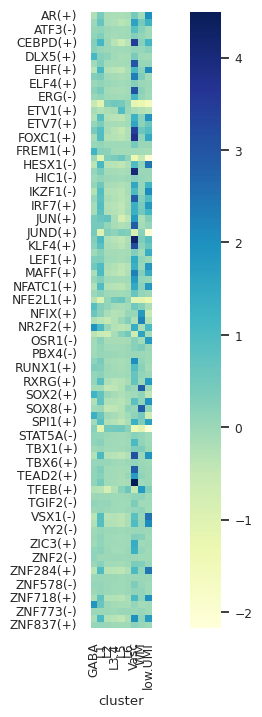

In [77]:
fig, ax1 = plt.subplots(1, 1, figsize=(10, 8))
sns.heatmap(df_z.T, ax=ax1, annot=False, square=True, linecolor='gray', 
            cmap="YlGnBu")

In [71]:
df_results[(df_results.Z >= 1.0)].sort_values('Z', ascending=False)

,cluster,regulon,Z
615,Vasc,TEAD3(+),4.490618
579,Vasc,KLF2(+),4.225227
569,Vasc,HEY2(+),4.058356
564,Vasc,FOXC1(+),3.775325
550,Vasc,CEBPD(+),3.464962
563,Vasc,FOS(+),3.415045
580,Vasc,KLF4(+),3.189543
611,Vasc,TBX18(+),3.069155
557,Vasc,ERG(+),3.055328
553,Vasc,EBF1(+),2.996696


In [56]:
df_results[(df_results.Z >= 3.0)].sort_values('Z', ascending=False).head()

,cluster,regulon,Z
615,Vasc,TEAD3(+),4.490618
579,Vasc,KLF2(+),4.225227
569,Vasc,HEY2(+),4.058356
564,Vasc,FOXC1(+),3.775325
550,Vasc,CEBPD(+),3.464962


In [ ]:
rss.T['L1'].sort_values(ascending=False)[0:5]

## Regulon specificity score

In [4]:
from pyscenic.rss import regulon_specificity_scores

In [ ]:
lf = lp.connect("/dcs04/lieber/marmaypag/spatialDLPFC_mdd_bpd_LIBD4100/spatialDLPFC_mdd_bpd/processed-data/09_SCENIC/spe-n119_21077_AUCell-output.loom", mode='r+', validate=False)
domain = pd.Series(lf.ca['smoothed_k9_1663'])
group = pd.Series(lf.ca['sex']+"_"+lf.ca['condition'])
lf.close()

In [5]:
rss = regulon_specificity_scores(auc_mtx, domain)
rss.head()

,AR(+),ATF3(+),ATF3(-),BARX2(+),CEBPD(+),DLX4(+),DLX5(+),EBF1(+),EHF(+),ELF1(+),...,ZNF283(+),ZNF284(+),ZNF296(+),ZNF578(-),ZNF699(+),ZNF718(+),ZNF730(+),ZNF773(-),ZNF836(+),ZNF837(+)
L3.4,0.189646,0.311062,0.186348,0.212442,0.358782,0.183929,0.198770,0.188594,0.225882,0.251815,...,0.186606,0.219155,0.170580,0.177138,0.187725,0.212088,0.186460,0.181449,0.233250,0.185459
L5,0.179963,0.241699,0.178802,0.208921,0.263144,0.178619,0.179259,0.182553,0.192734,0.215354,...,0.179567,0.190101,0.169838,0.173570,0.183130,0.191166,0.179125,0.183988,0.195983,0.179017
L6,0.195081,0.269457,0.186430,0.216775,0.297173,0.184903,0.183342,0.187680,0.235950,0.232906,...,0.190879,0.229850,0.171082,0.176571,0.189643,0.221530,0.181416,0.186118,0.237918,0.182237
low.UMI,0.408687,0.271048,0.176308,0.184844,0.246079,0.230126,0.177013,0.185811,0.338245,0.192334,...,0.180673,0.364033,0.169353,0.170318,0.175089,0.354826,0.179080,0.170469,0.320383,0.174351
L2,0.187646,0.283291,0.193029,0.216155,0.336522,0.189869,0.231450,0.188969,0.222107,0.246130,...,0.187144,0.214291,0.170860,0.177025,0.189598,0.207398,0.205216,0.181385,0.231902,0.191895


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyscenic.plotting import plot_rss

In [ ]:
def plot_rss(rss, cell_type, top_n=5, max_n=None, ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(4, 4))
    if max_n is None:
        max_n = rss.shape[1]
    data = rss.T[cell_type].sort_values(ascending=False)[0:max_n]
    ax.plot(np.arange(len(data)), data, ".")
    ax.set_ylim([floor(data.min() * 100.0) / 100.0, ceil(data.max() * 100.0) / 100.0])
    ax.set_ylabel("RSS")
    ax.set_xlabel("Regulon")
    ax.set_title(cell_type)
    ax.set_xticklabels([])

    font = {
        "color": "red",
        "weight": "normal",
        "size": 4,
    }

    for idx, (regulon_name, rss_val) in enumerate(
        zip(data[0:top_n].index, data[0:top_n].values)
    ):
        ax.plot([idx, idx], [rss_val, rss_val], "r.")
        ax.text(
            idx + (max_n / 25),
            rss_val,
            regulon_name,
            fontdict=font,
            horizontalalignment="left",
            verticalalignment="center",
        )

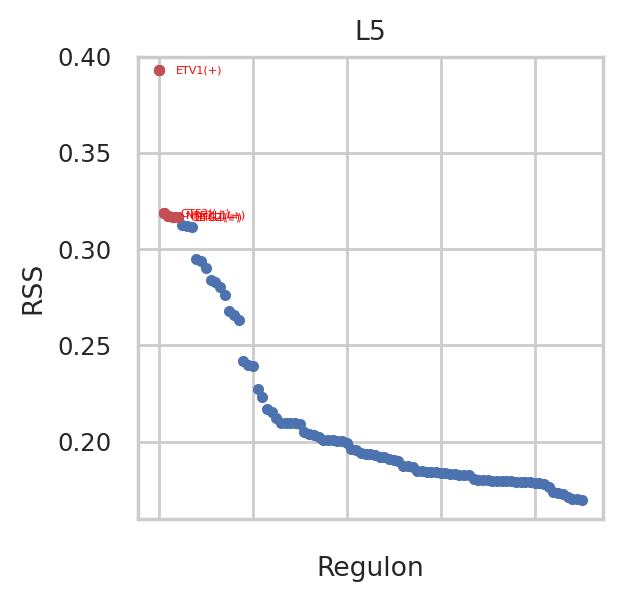

In [19]:
fig, ax1 = plt.subplots(1, 1, figsize=(3, 3), dpi=200)
plot_rss(rss, 'L5', ax=ax1)

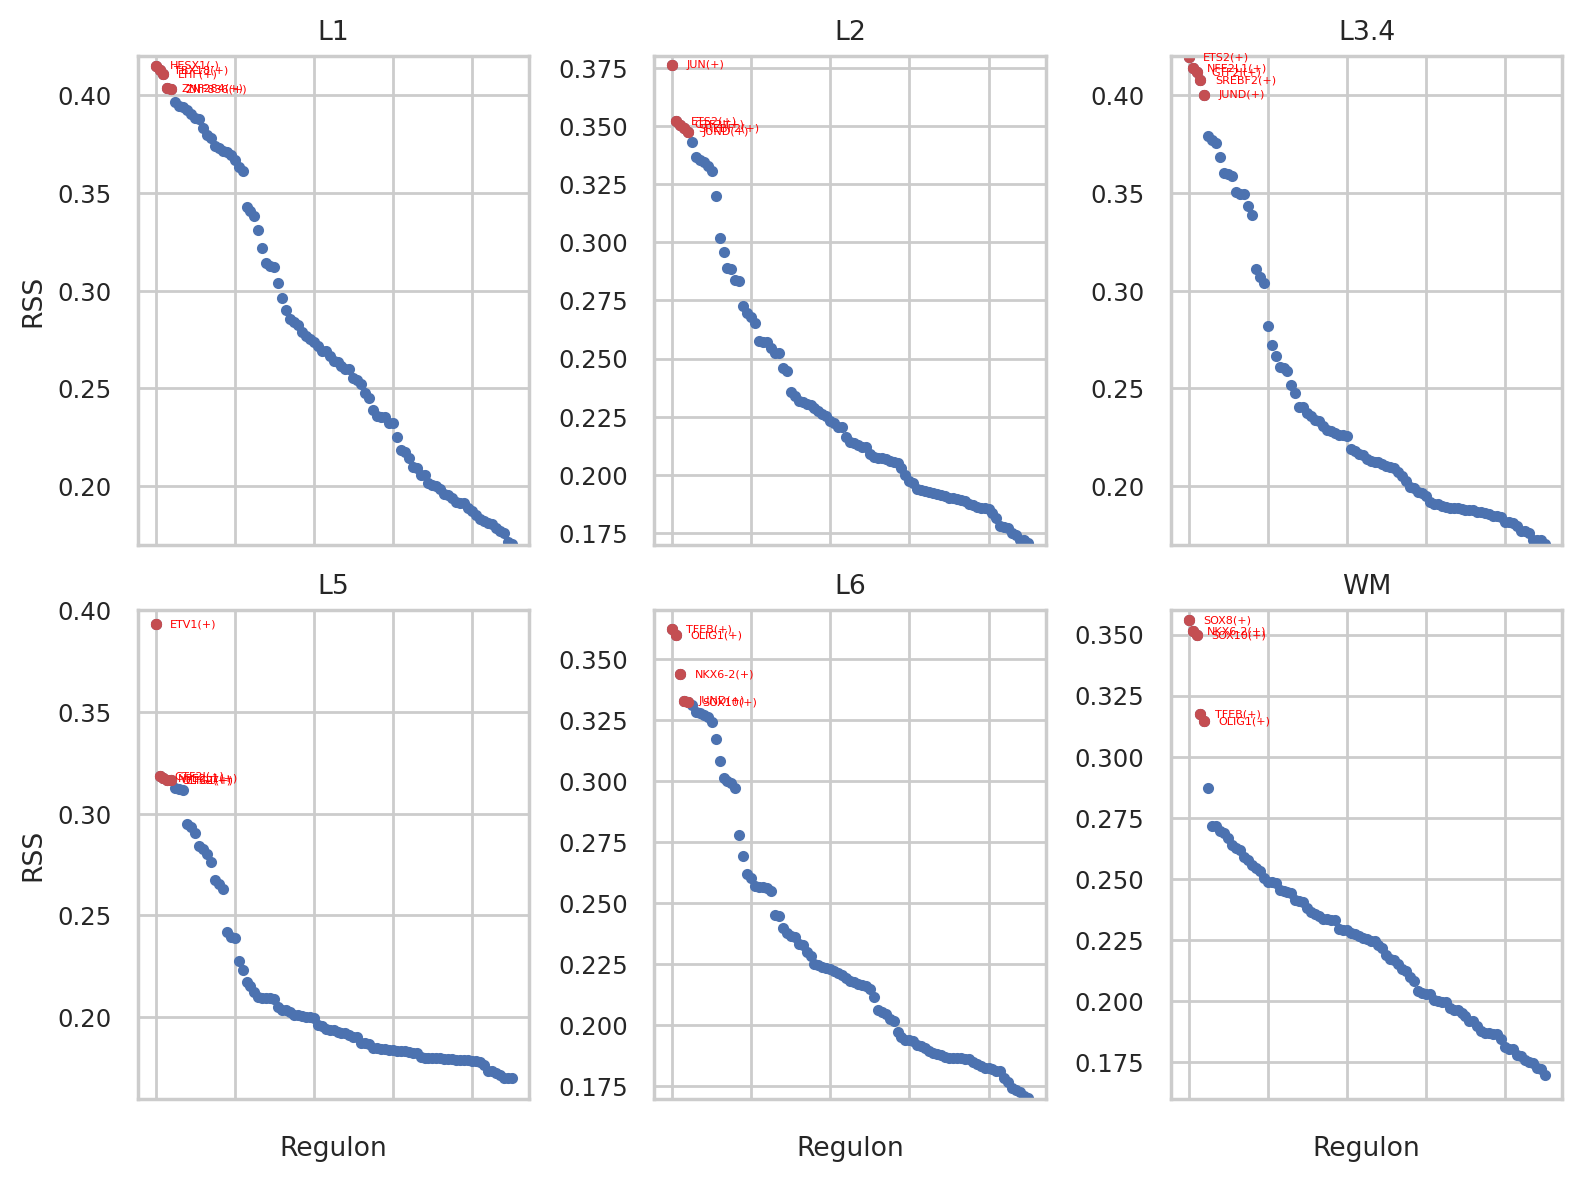

In [7]:
sns.set()
sns.set(style='whitegrid', font_scale=0.8)
fig, ((ax1, ax2, ax3), (ax5, ax6, ax7)) = plt.subplots(2, 3, figsize=(8, 6), dpi=200)
plot_rss(rss, 'L1', ax=ax1)
ax1.set_xlabel('')
plot_rss(rss, 'L2', ax=ax2)
ax2.set_xlabel('')
ax2.set_ylabel('')
plot_rss(rss, 'L3.4', ax=ax3)
ax3.set_xlabel('')
ax3.set_ylabel('')
plot_rss(rss, 'L5', ax=ax5)
plot_rss(rss, 'L6', ax=ax6)
ax6.set_ylabel('')
plot_rss(rss, 'WM', ax=ax7)
ax7.set_ylabel('')
plt.tight_layout()
#savesvg('plots - GSE115978 - rss.svg', fig)

In [11]:
rss.T['L1'].sort_values(ascending=False)[0:5]

HESX1(-)     0.415265
TBX18(+)     0.413104
EHF(+)       0.410949
ZNF284(+)    0.403841
ZNF836(+)    0.403226
Name: L1, dtype: float32

In [13]:
rss.T['L2'].sort_values(ascending=False)[0:5]

JUN(+)       0.376268
ETS2(+)      0.352200
GTF2I(+)     0.350645
SREBF2(+)    0.349298
JUND(+)      0.347617
Name: L2, dtype: float32

In [14]:
rss.T['L3.4'].sort_values(ascending=False)[0:5]

ETS2(+)      0.419535
NFE2L1(+)    0.413944
GTF2I(+)     0.412010
SREBF2(+)    0.408037
JUND(+)      0.400242
Name: L3.4, dtype: float32

In [15]:
rss.T['L5'].sort_values(ascending=False)[0:5]

ETV1(+)      0.393019
GTF2I(+)     0.318562
NFE2L1(+)    0.317315
OLIG1(+)     0.316524
ETS2(+)      0.316448
Name: L5, dtype: float32

In [16]:
rss.T['L6'].sort_values(ascending=False)[0:5]

TFEB(+)      0.362403
OLIG1(+)     0.359949
NKX6-2(+)    0.343687
JUND(+)      0.332917
SOX10(+)     0.332518
Name: L6, dtype: float32

In [17]:
rss.T['WM'].sort_values(ascending=False)[0:5]

SOX8(+)      0.356048
NKX6-2(+)    0.351265
SOX10(+)     0.349793
TFEB(+)      0.317357
OLIG1(+)     0.314467
Name: WM, dtype: float32

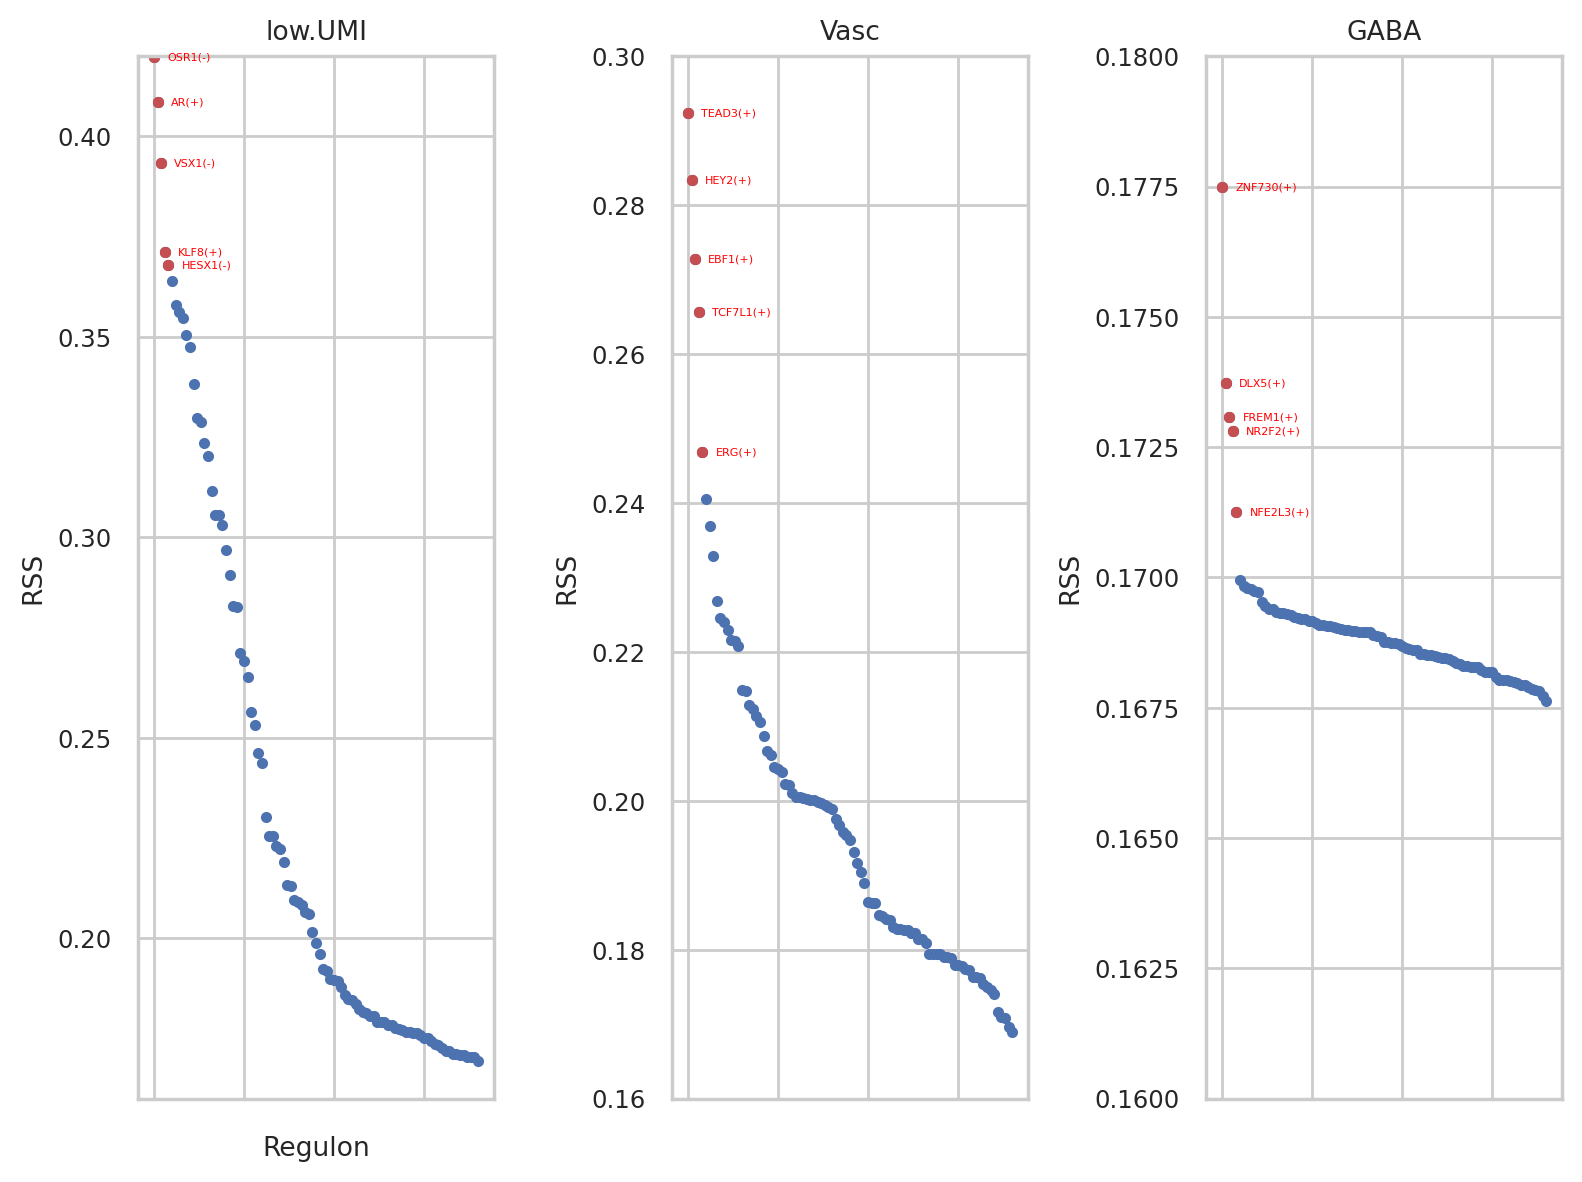

In [8]:
sns.set()
sns.set(style='whitegrid', font_scale=0.8)
fig, ((ax1, ax2, ax3)) = plt.subplots(1, 3, figsize=(8, 6), dpi=200)
plot_rss(rss, 'low.UMI', ax=ax1)
plot_rss(rss, 'Vasc', ax=ax2)
ax2.set_xlabel('')
plot_rss(rss, 'GABA', ax=ax3)
ax3.set_xlabel('')
plt.tight_layout()
#savesvg('plots - GSE115978 - rss.svg', fig)

In [18]:
rss.T['Vasc'].sort_values(ascending=False)[0:5]

TEAD3(+)     0.292373
HEY2(+)      0.283423
EBF1(+)      0.272769
TCF7L1(+)    0.265694
ERG(+)       0.246848
Name: Vasc, dtype: float32

In [67]:
rss = regulon_specificity_scores(auc_mtx, group)
rss.head()

,AR(+),ATF3(+),ATF3(-),BARX2(+),CEBPD(+),DLX4(+),DLX5(+),EBF1(+),EHF(+),ELF1(+),...,ZNF283(+),ZNF284(+),ZNF296(+),ZNF578(-),ZNF699(+),ZNF718(+),ZNF730(+),ZNF773(-),ZNF836(+),ZNF837(+)
M_NTC,0.228812,0.300794,0.192366,0.217881,0.314149,0.192046,0.199455,0.196569,0.269905,0.239481,...,0.192411,0.266375,0.170685,0.178086,0.188525,0.256460,0.201063,0.190035,0.271979,0.186704
F_NTC,0.218515,0.287281,0.192408,0.215813,0.310763,0.189518,0.202892,0.198757,0.256139,0.247271,...,0.191240,0.253102,0.171082,0.178034,0.186817,0.244807,0.204223,0.173351,0.261684,0.187041
F_MDD,0.217480,0.319555,0.199870,0.217298,0.333985,0.189843,0.203169,0.201151,0.257808,0.275129,...,0.194160,0.252910,0.171055,0.177576,0.190064,0.244682,0.198844,0.173958,0.264033,0.184832
M_BPD,0.223310,0.292245,0.189385,0.218560,0.324684,0.190955,0.200778,0.197142,0.263585,0.246874,...,0.197233,0.258544,0.170882,0.175813,0.189791,0.249909,0.197928,0.188959,0.264918,0.185713
F_BPD,0.217118,0.295215,0.190624,0.218842,0.324200,0.192913,0.203807,0.200083,0.256374,0.251458,...,0.196079,0.251605,0.170418,0.177723,0.189561,0.243593,0.200272,0.173964,0.260915,0.185588


<Axes: xlabel='F_NTC', ylabel='F_MDD'>

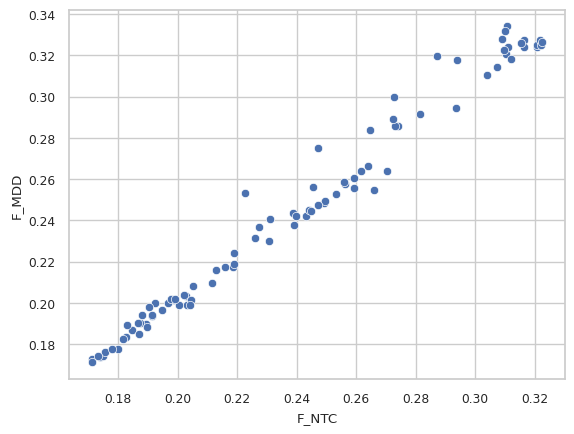

In [69]:
sns.scatterplot(rss.T, x='F_NTC', y='F_MDD')

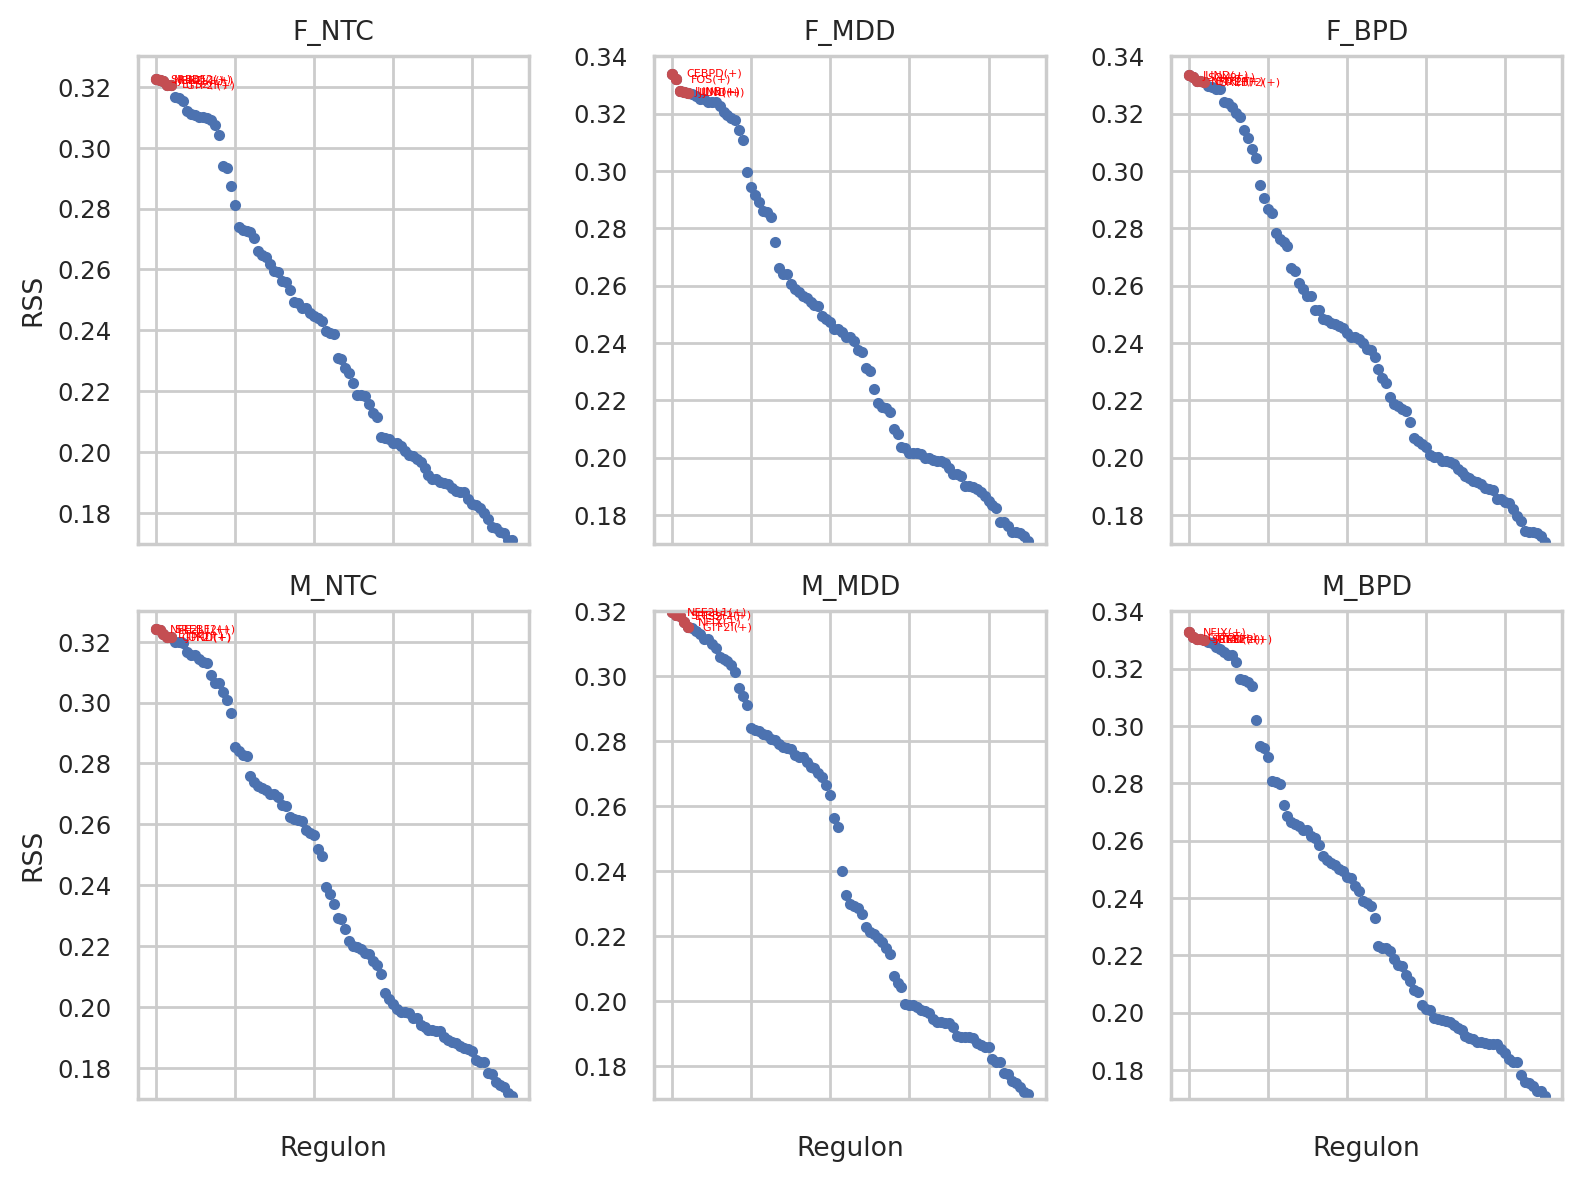

In [68]:
sns.set()
sns.set(style='whitegrid', font_scale=0.8)
fig, ((ax1, ax2, ax3), (ax5, ax6, ax7)) = plt.subplots(2, 3, figsize=(8, 6), dpi=200)
plot_rss(rss, 'F_NTC', ax=ax1)
ax1.set_xlabel('')
plot_rss(rss, 'F_MDD', ax=ax2)
ax2.set_xlabel('')
ax2.set_ylabel('')
plot_rss(rss, 'F_BPD', ax=ax3)
ax3.set_xlabel('')
ax3.set_ylabel('')
plot_rss(rss, 'M_NTC', ax=ax5)
plot_rss(rss, 'M_MDD', ax=ax6)
ax6.set_ylabel('')
plot_rss(rss, 'M_BPD', ax=ax7)
ax7.set_ylabel('')
plt.tight_layout()
#savesvg('plots - GSE115978 - rss.svg', fig)

## Binarization

In [4]:
 bin_mtx, thresholds = binarize(auc_mtx)

In [5]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from pyscenic.plotting import plot_binarization

from IPython.display import HTML, display

/users/jthompso/.conda/envs/pyscenic/lib/python3.10/site-packages/pyscenic/plotting.py:22: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(auc_mtx[regulon_name], ax=ax, norm_hist=True, bins=bins)
/users/jthompso/.conda/envs/pyscenic/lib/python3.10/site-packages/pyscenic/plotting.py:22: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed29744

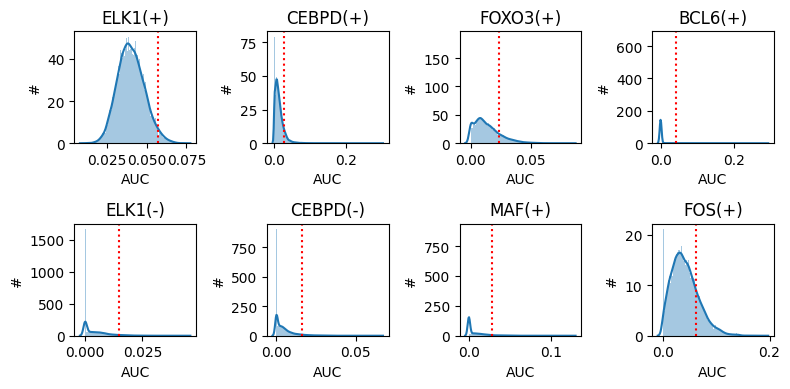

In [7]:
fig, ((ax1, ax2, ax3, ax4), (ax5, ax6, ax7, ax8)) = plt.subplots(2, 4, figsize=(8, 4), dpi=100)

plot_binarization(auc_mtx, 'ELK1(+)', thresholds['ELK1(+)'], ax=ax1)
plot_binarization(auc_mtx, 'CEBPD(+)', thresholds['CEBPD(+)'], ax=ax2)
plot_binarization(auc_mtx, 'FOXO3(+)', thresholds['FOXO3(+)'], ax=ax3)
plot_binarization(auc_mtx, 'BCL6(+)', thresholds['BCL6(+)'], ax=ax4)
plot_binarization(auc_mtx, 'ELK1(-)', thresholds['ELK1(-)'], ax=ax5)
plot_binarization(auc_mtx, 'CEBPD(-)', thresholds['CEBPD(-)'], ax=ax6)
plot_binarization(auc_mtx, 'MAF(+)', thresholds['MAF(+)'], ax=ax7)
plot_binarization(auc_mtx, 'FOS(+)', thresholds['FOS(+)'], ax=ax8)

plt.tight_layout()

In [17]:
auc_mtx

,AHR(+),AR(-),ARID3A(+),ARID3A(-),ARNTL(-),ARNTL2(-),ARX(+),ASCL1(+),ASCL1(-),ATF1(-),...,ZNF81(-),ZNF821(+),ZNF83(-),ZNF91(+),ZSCAN29(+),ZSCAN30(+),ZSCAN30(-),ZSCAN32(+),ZSCAN32(-),ZSCAN9(-)
ACGCCTGACACGCGCT-1_V13B23-329_A1,0.0,0.000000,0.032585,0.050702,0.000000,0.000000,0.012974,0.0,0.000000,0.003276,...,0.0,0.048018,0.000000,0.0,0.060886,0.000000,0.0,0.000000,0.442775,0.000000
GACCTGGTCTGGGCGT-1_V13B23-329_A1,0.0,0.000000,0.009544,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.018015,0.000000,0.0,0.000000,0.000000,0.000000
CGTCCAGATGGCTCCA-1_V13B23-329_A1,0.0,0.000000,0.001425,0.002395,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.010074,0.000000,0.0,0.015944,0.000000,0.0,0.000000,0.000000,0.000000
TCGCACTAACGTTTGT-1_V13B23-329_A1,0.0,0.000000,0.000780,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000915,0.029690,0.0,0.000000,0.000000,0.000000
TAGAAACACAATAGTG-1_V13B23-329_A1,0.0,0.123699,0.021024,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CTGGTAAAGACTTACA-1_V13B23-329_D1,0.0,0.000000,0.014948,0.000000,0.000000,0.000000,0.000856,0.0,0.000000,0.000000,...,0.0,0.038150,0.000000,0.0,0.034393,0.000000,0.0,0.016185,0.000000,0.000000
ACATTTGAAACCTAAC-1_V13B23-329_D1,0.0,0.019268,0.008146,0.023287,0.000000,0.000000,0.000000,0.0,0.040029,0.015286,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
AGAATACAGGCTATCC-1_V13B23-329_D1,0.0,0.056069,0.000000,0.000000,0.016570,0.000000,0.014644,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000145,0.004782,0.0,0.000000,0.000000,0.000000
ACCTCAGCGAGGCGCA-1_V13B23-329_D1,0.0,0.000000,0.012555,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.034923,0.004256,0.0,0.000000,0.000000,0.000000


In [20]:
auc_mtx.columns.str.replace('\(+)','_plus')

Index(['AHR(+)', 'AR(-)', 'ARID3A(+)', 'ARID3A(-)', 'ARNTL(-)', 'ARNTL2(-)',
       'ARX(+)', 'ASCL1(+)', 'ASCL1(-)', 'ATF1(-)',
       ...
       'ZNF81(-)', 'ZNF821(+)', 'ZNF83(-)', 'ZNF91(+)', 'ZSCAN29(+)',
       'ZSCAN30(+)', 'ZSCAN30(-)', 'ZSCAN32(+)', 'ZSCAN32(-)', 'ZSCAN9(-)'],
      dtype='object', length=597)

In [16]:
auc_mtx.columns = auc_mtx.columns.str.replace('\(','_(')

### https://github.com/aertslab/SCENICprotocol/blob/master/notebooks/PBMC10k_SCENIC-protocol-CLI.ipynb

In [11]:
import json
import zlib
import base64

In [12]:
lf = lp.connect("/dcs04/lieber/marmaypag/spatialDLPFC_mdd_bpd_LIBD4100/spatialDLPFC_mdd_bpd/processed-data/09_SCENIC/single-slide_AUCell-output.loom", mode='r+', validate=False)
regulons = lf.ra.Regulons
meta = json.loads(zlib.decompress(base64.b64decode( lf.attrs.MetaData )))
lf.close()

In [13]:
# regulon thresholds
rt = meta['regulonThresholds']
for i,x in enumerate(rt):
    tmp = x.get('regulon').replace("(","_(")
    x.update( {'regulon': tmp} )

In [14]:
rt

[{'regulon': 'AHR_(+)',
  'defaultThresholdValue': 0.03442186707683484,
  'defaultThresholdName': 'gaussian_mixture_split',
  'allThresholds': {'gaussian_mixture_split': 0.03442186707683484},
  'motifData': 'metacluster_198.7.png'},
 {'regulon': 'AR_(-)',
  'defaultThresholdValue': 0.0953653514602273,
  'defaultThresholdName': 'gaussian_mixture_split',
  'allThresholds': {'gaussian_mixture_split': 0.0953653514602273},
  'motifData': 'taipale_tf_pairs__TEAD4_ESRRB_RCATTCYNNNNCAAGGTCAN_CAP_repr.png'},
 {'regulon': 'ARID3A_(+)',
  'defaultThresholdValue': 0.03849736494269228,
  'defaultThresholdName': 'gaussian_mixture_split',
  'allThresholds': {'gaussian_mixture_split': 0.03849736494269228},
  'motifData': 'metacluster_9.29.png'},
 {'regulon': 'ARID3A_(-)',
  'defaultThresholdValue': 0.04131331212670209,
  'defaultThresholdName': 'gaussian_mixture_split',
  'allThresholds': {'gaussian_mixture_split': 0.04131331212670209},
  'motifData': 'tfdimers__MD00423.png'},
 {'regulon': 'ARNTL_(-)'